# Match Result Prediction with Spark MLlib

This notebook trains a multiclass classifier on historical prepared matches and evaluates it on the scraped current-season dataset (2025-2026).

In [9]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

candidate = globals().get("spark", None)

def is_usable_session(s):
    if s is None:
        return False
    try:
        return not s.sparkContext._jsc.sc().isStopped()
    except Exception:
        return False

if not is_usable_session(candidate):
    try:
        stale = SparkSession._instantiatedSession
        if stale is not None:
            try:
                stale.stop()
            except Exception:
                pass
    except Exception:
        pass

    SparkSession._instantiatedSession = None
    SparkSession._activeSession = None

    spark = (
        SparkSession.builder
        .appName("Football_ML_Part5")
        .master("spark://spark-master:7077")
        .config("spark.sql.shuffle.partitions", "4")
        .getOrCreate()
    )
else:
    spark = candidate

spark.sparkContext.setLogLevel("ERROR")
print("Spark session active:", spark.version)

HIST_PARQUET_PATH = "/workspace/data/outputs/prepared/historical/"
train_df = spark.read.parquet(HIST_PARQUET_PATH)

train_rows_raw = train_df.count()
print("TRAIN ROWS RAW:", train_rows_raw)

if train_rows_raw == 0:
    raise ValueError(
        "Historical parquet is empty. Please rerun the historical preparation section first."
    )

TEST_CSV_PATH = "/workspace/data/outputs/prepared/current_season/current_season_clean.csv"
test_df = spark.read.csv(TEST_CSV_PATH, header=True, inferSchema=True)

print("TEST CSV PATH:", TEST_CSV_PATH)
print("TEST ROWS RAW:", test_df.count())
test_df.select(min("date").alias("min_date"), max("date").alias("max_date")).show(truncate=False)

train_df = train_df.dropna(subset=["home_team", "away_team", "result", "home_goals", "away_goals"])
test_df = test_df.dropna(subset=["home_team", "away_team", "result", "date", "home_goals", "away_goals"])

test_df = test_df.withColumn("date", to_date(col("date"), "yyyy-MM-dd"))
test_df = test_df.filter(col("date").isNotNull())

print("TRAIN ROWS AFTER CLEAN:", train_df.count())
print("TEST ROWS AFTER CLEAN:", test_df.count())

Spark session active: 3.5.3
TRAIN ROWS RAW: 2590
TEST CSV PATH: /workspace/data/outputs/prepared/current_season/current_season_clean.csv
TEST ROWS RAW: 151
+----------+----------+
|min_date  |max_date  |
+----------+----------+
|2025-10-03|2026-04-25|
+----------+----------+

TRAIN ROWS AFTER CLEAN: 2590
TEST ROWS AFTER CLEAN: 151


## Target Definition and Feature Engineering

Create the target label and build the pre-match aggregate features used by the classifier.

In [10]:
label_expr = (
    when(col("result") == "home_win", 0)
    .when(col("result") == "draw", 1)
    .otherwise(2)
)

train_df = train_df.withColumn("label", label_expr)
test_df = test_df.withColumn("label", label_expr)

home_hist = train_df.groupBy("home_team").agg(avg("home_goals").alias("avg_home_goals_scored"))
away_hist = train_df.groupBy("away_team").agg(avg("away_goals").alias("avg_away_goals_scored"))

train_df = train_df.join(home_hist, on="home_team", how="left").join(away_hist, on="away_team", how="left")
test_df = test_df.join(home_hist, on="home_team", how="left").join(away_hist, on="away_team", how="left")

train_df = train_df.fillna({"avg_home_goals_scored": 0.0, "avg_away_goals_scored": 0.0})
test_df = test_df.fillna({"avg_home_goals_scored": 0.0, "avg_away_goals_scored": 0.0})

train_df = train_df.withColumn(
    "match_year",
    coalesce(
        col("match_year"),
        year(col("date")),
        regexp_extract(col("season"), r"(\d{4})", 1).cast("int"),
        lit(2025),
    ),
)

test_df = test_df.withColumn("match_year", coalesce(col("match_year"), year(col("date")), lit(2026)))

print("TRAIN ROWS FINAL:", train_df.count())
print("TEST ROWS FINAL:", test_df.count())

if test_df.count() < 50:
    raise ValueError("Test set is unexpectedly small. Please verify the scraped output file.")

train_df = train_df.withColumn(
    "form_gap",
    col("avg_home_goals_scored") - col("avg_away_goals_scored"),
)
test_df = test_df.withColumn(
    "form_gap",
    col("avg_home_goals_scored") - col("avg_away_goals_scored"),
)

TRAIN ROWS FINAL: 2590
TEST ROWS FINAL: 151


## Model Training Pipeline

Train a multiclass Logistic Regression model using team and temporal features.

In [23]:
home_indexer = StringIndexer(inputCol="home_team", outputCol="home_team_idx", handleInvalid="keep")
away_indexer = StringIndexer(inputCol="away_team", outputCol="away_team_idx", handleInvalid="keep")

assembler = VectorAssembler(
    inputCols=[
        "home_team_idx",
        "away_team_idx",
        "match_year",
        "avg_home_goals_scored",
        "avg_away_goals_scored",
        "form_gap",
    ],
    outputCol="features",
    handleInvalid="keep",
)

clf = LogisticRegression(featuresCol="features", labelCol="label", maxIter=80, regParam=0.05)

pipeline = Pipeline(stages=[home_indexer, away_indexer, assembler, clf])
model = pipeline.fit(train_df)

## Evaluation and Sample Predictions

Evaluate the trained model on scraped current-season matches and inspect prediction examples.

In [24]:
pred = model.transform(test_df)

acc_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="accuracy")
f1_eval = MulticlassClassificationEvaluator(labelCol="label", predictionCol="prediction", metricName="f1")

accuracy = acc_eval.evaluate(pred)
f1_score = f1_eval.evaluate(pred)

print("\n================= PART 5 RESULTS =================")
print(f"Accuracy (test scraped): {float(accuracy):.4f}")
print(f"F1-score (test scraped): {float(f1_score):.4f}")
print("==================================================")

label_to_text = (
    when(col("prediction") == 0.0, lit("home_win"))
    .when(col("prediction") == 1.0, lit("draw"))
    .otherwise(lit("away_win"))
)

sample_pred = pred.withColumn("predicted_result", label_to_text)

sample_pred.select(
    "date",
    "home_team",
    "away_team",
    "result",
    "predicted_result",
    "probability",
).orderBy(col("date").desc()).show(15, truncate=False)

print("\nModel limitations:")
print("- Limited pre-match features (no injuries, odds, or player-level context).")
print("- Team renaming/new teams may reduce generalization quality.")
print("- Logistic regression is intentionally simple for interpretability.")


================= PART 5 RESULTS =================
Accuracy (test scraped): 0.4040
F1-score (test scraped): 0.3115
+----------+------------------+------------------+--------+----------------+-------------------------------------------------------------+
|date      |home_team         |away_team         |result  |predicted_result|probability                                                  |
+----------+------------------+------------------+--------+----------------+-------------------------------------------------------------+
|2026-04-25|Kaedi             |Nouadhibou        |away_win|away_win        |[0.17302807600877937,0.23413645444915562,0.592835469542065]  |
|2026-04-24|SNIM              |Nzeidane          |draw    |home_win        |[0.569742573997645,0.2545164953043811,0.17574093069797395]   |
|2026-04-13|Gendrim           |Tevragh-Zeina     |draw    |away_win        |[0.1988420667533359,0.2466137063187614,0.5545442269279028]   |
|2026-04-12|Nouakchott Academy|Police            |

## Bonus 2: Multi-Model Comparison

Train a Random Forest baseline on the same features and compare metrics against Logistic Regression.

In [25]:
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=120, maxDepth=8, maxBins=128, seed=42)

rf_pipeline = Pipeline(stages=[home_indexer, away_indexer, assembler, rf])
rf_model = rf_pipeline.fit(train_df)
rf_pred = rf_model.transform(test_df)

rf_accuracy = acc_eval.evaluate(rf_pred)
rf_f1 = f1_eval.evaluate(rf_pred)

comparison_df = spark.createDataFrame(
    [
        ("LogisticRegression", float(accuracy), float(f1_score)),
        ("RandomForest", float(rf_accuracy), float(rf_f1)),
    ],
    ["model", "accuracy", "f1_score"],
)

comparison_df.show(truncate=False)

+------------------+-------------------+-------------------+
|model             |accuracy           |f1_score           |
+------------------+-------------------+-------------------+
|LogisticRegression|0.40397350993377484|0.3114848010373934 |
|RandomForest      |0.423841059602649  |0.40234369524971997|
+------------------+-------------------+-------------------+



## Bonus 3: Final Notebook Visualization

Visualize model comparison metrics and top scoring home teams in the current-season test set.

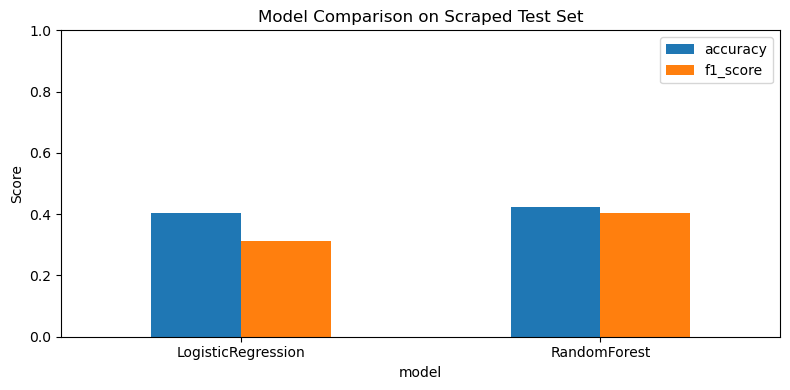

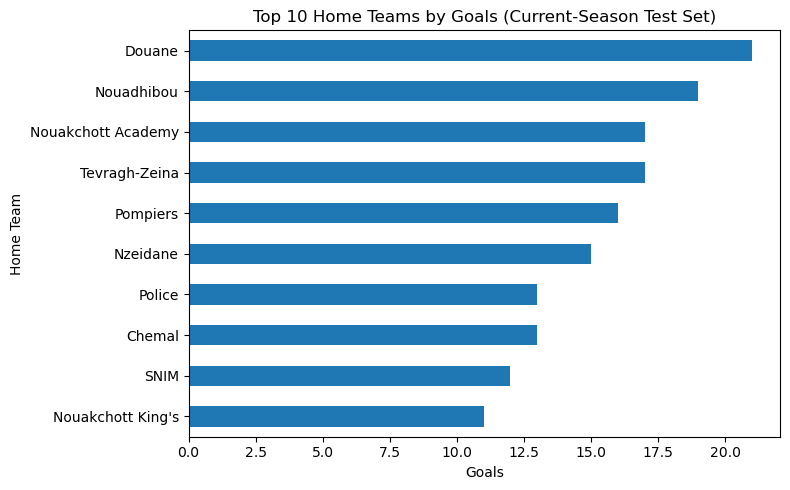

In [26]:
import matplotlib.pyplot as plt

comparison_pd = comparison_df.toPandas()

ax = comparison_pd.set_index("model")[["accuracy", "f1_score"]].plot(
    kind="bar",
    figsize=(8, 4),
    rot=0,
    title="Model Comparison on Scraped Test Set"
)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
plt.tight_layout()
plt.show()

top_home_pd = (
    test_df.groupBy("home_team")
    .agg(sum("home_goals").alias("home_goals_total"))
    .orderBy(col("home_goals_total").desc())
    .limit(10)
    .toPandas()
)

ax2 = top_home_pd.sort_values("home_goals_total").plot(
    kind="barh",
    x="home_team",
    y="home_goals_total",
    figsize=(8, 5),
    legend=False,
    title="Top 10 Home Teams by Goals (Current-Season Test Set)"
)
ax2.set_xlabel("Goals")
ax2.set_ylabel("Home Team")
plt.tight_layout()
plt.show()

## Bonus Notes

1. Bonus 1: Implemented `form_gap` as a recent-team-form proxy feature.
2. Bonus 2: Implemented model comparison between Logistic Regression and Random Forest.
3. Bonus 3: Added final notebook visualizations for model metrics and scoring teams.

## Saving Models

In [27]:
import os

models_root = "/workspace/data/outputs/models"
os.makedirs(models_root, exist_ok=True)

lr_model_path = f"{models_root}/logistic_regression_pipeline"
rf_model_path = f"{models_root}/random_forest_pipeline"

model.write().overwrite().save(lr_model_path)
rf_model.write().overwrite().save(rf_model_path)

print("Saved model:", lr_model_path)
print("Saved model:", rf_model_path)

Saved model: /workspace/data/outputs/models/logistic_regression_pipeline
Saved model: /workspace/data/outputs/models/random_forest_pipeline
